In [1]:
# "Pakistan Ecommerce Business Intelligence Report"
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(r'E:\Github\Pakistan Largest Ecommerce Dataset.csv', encoding='latin-1',  nrows = 50000, usecols=['category_name_1', 'payment_method', 'grand_total', 'status', 'Month'])
df.shape

(50000, 5)

In [3]:
df.head(5)
df.isnull().sum()
df.describe()

,grand_total,Month
count,5.000000e+04,50000.000000
mean,5.931004e+03,8.721140
std,2.218735e+04,1.099128
min,0.000000e+00,7.000000
25%,3.350000e+02,8.000000
50%,8.300000e+02,9.000000
75%,3.055000e+03,10.000000
max,1.280473e+06,11.000000


In [9]:
df['category_name_1'].value_counts().head(5)
df['payment_method'].value_counts()
df['status'].value_counts()

payment_method
cod                  36778
Payaxis               9478
ublcreditcard          882
cashatdoorstep         672
mygateway              669
customercredit         571
internetbanking        398
mcblite                383
productcredit          125
marketingexpense        43
financesettlement        1
Name: count, dtype: int64

In [13]:
df.groupby('category_name_1')['grand_total'].mean().round(2)
df.groupby('payment_method')['grand_total'].sum()

payment_method
Payaxis              1.095825e+08
cashatdoorstep       1.010899e+06
cod                  1.301851e+08
customercredit       0.000000e+00
financesettlement    4.212000e+03
internetbanking      5.642459e+06
marketingexpense     2.603630e+05
mcblite              6.646669e+06
mygateway            2.127147e+07
productcredit        0.000000e+00
ublcreditcard        2.194650e+07
Name: grand_total, dtype: float64

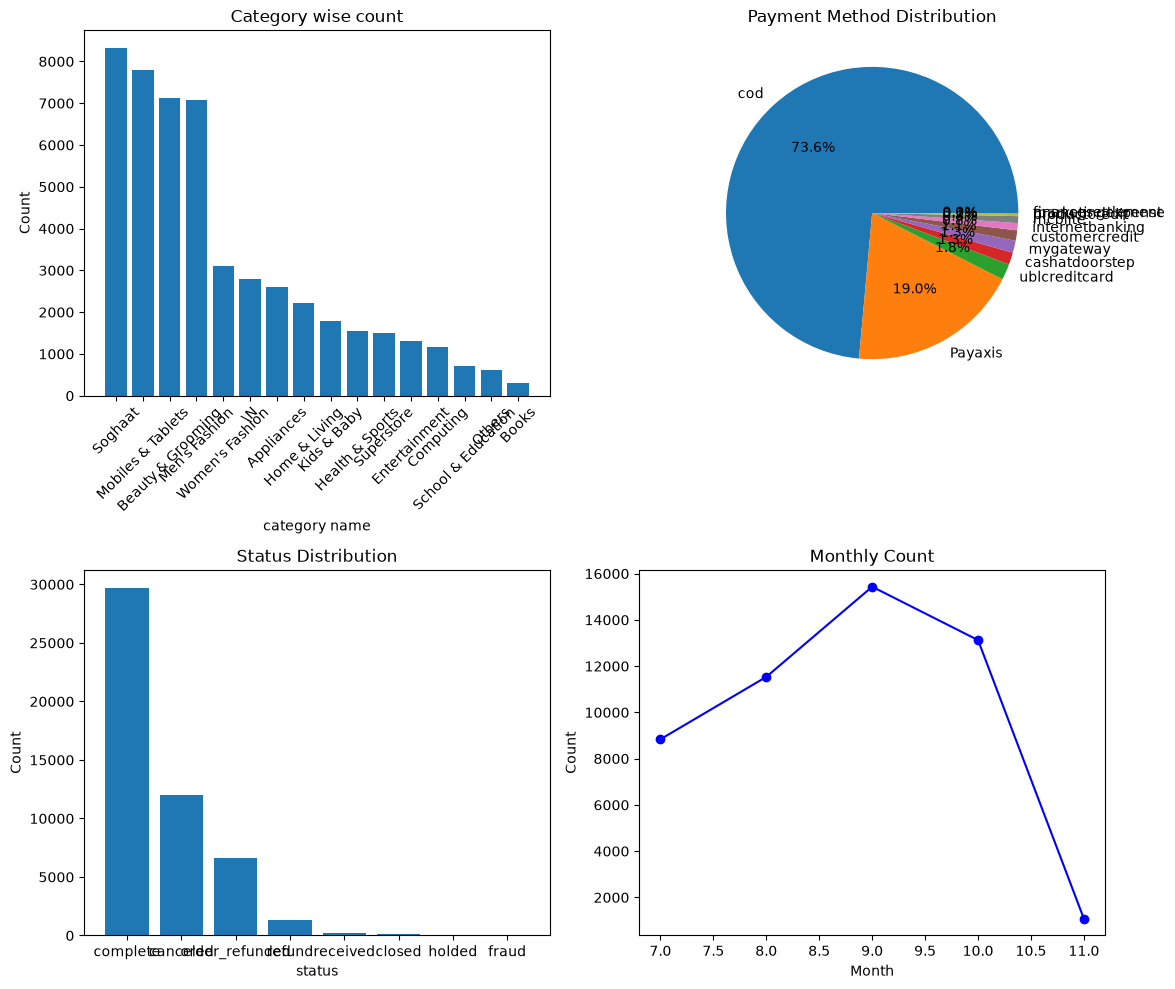

In [27]:
fig, axes = plt.subplots(2,2, figsize=(12,10))
axes[0,0].bar(df['category_name_1'].value_counts().index, df['category_name_1'].value_counts())
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].set_title('Category wise count')
axes[0,0].set_xlabel('category name')
axes[0,0].set_ylabel("Count")
axes[0,1].pie(df['payment_method'].value_counts(), labels=df['payment_method'].value_counts().index, autopct='%1.1f%%')
axes[0,1].set_title('Payment Method Distribution')  
axes[1,0].bar(df['status'].value_counts().index, df['status'].value_counts())
axes[1,0].set_title('Status Distribution')
axes[1,0].set_xlabel('status')
axes[1,0].set_ylabel("Count")
monthly = df['Month'].value_counts().sort_index()
axes[1,1].plot(monthly.index, monthly.values, marker='o', linestyle='-', color='b')
axes[1,1].set_title('Monthly Count')
axes[1,1].set_xlabel('Month')
axes[1,1].set_ylabel("Count")
plt.tight_layout()
plt.show()

In [28]:
print("=" * 50)
print("  PAKISTAN ECOMMERCE — BI REPORT")
print("=" * 50)
print(f"\nTotal orders: {len(df):,}")
print(f"Top category: {df['category_name_1'].value_counts().index[0]}")
print(f"Top payment: {df['payment_method'].value_counts().index[0]}")
print(f"Avg order: Rs. {df['grand_total'].mean():.0f}")
print(f"Complete orders: {df[df['status']=='complete']['status'].count():,}")
print("=" * 50)

  PAKISTAN ECOMMERCE — BI REPORT

Total orders: 50,000
Top category: Soghaat
Top payment: cod
Avg order: Rs. 5931
Complete orders: 29,733
